In [1]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git
!ls pubmed-rct

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 37.68 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (13/13), done.
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
README.md


In [2]:
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign

dev.txt  test.txt  train.txt


In [1]:
data_dir = "pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [2]:
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt']

## Preprocess data

In [3]:
# To read lines of a document
def get_lines(filename):
  with open(filename, "r") as f:
    return f.readlines()

In [4]:
train_lines = get_lines(data_dir+"train.txt")
train_lines[:10]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [5]:
def preprocess_text_with_line_numbers(filename):
  input_lines = get_lines(filename)
  abstract_lines = ""
  abstract_samples = []

  for line in input_lines:
    if line.startswith("###"):
      abstract_id = line
      abstract_lines = ""
    elif line.isspace():
      abstract_line_split = abstract_lines.splitlines()

      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {}
        target_text_split = abstract_line.split("\t")
        line_data["target"] = target_text_split[0]
        line_data["text"] = target_text_split[1].lower()
        line_data["line_number"] = abstract_line_number
        line_data["total_lines"] = len(abstract_line_split) - 1
        abstract_samples.append(line_data)

    else:
      abstract_lines += line

  return abstract_samples

In [6]:
train_samples = preprocess_text_with_line_numbers(data_dir + "train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir + "dev.txt")
test_samples = preprocess_text_with_line_numbers(data_dir + "test.txt")
len(train_samples), len(val_samples), len(test_samples)

(180040, 30212, 30135)

In [7]:
train_samples[:10]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [8]:
import pandas as pd
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
train_df.head(14)

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [9]:
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


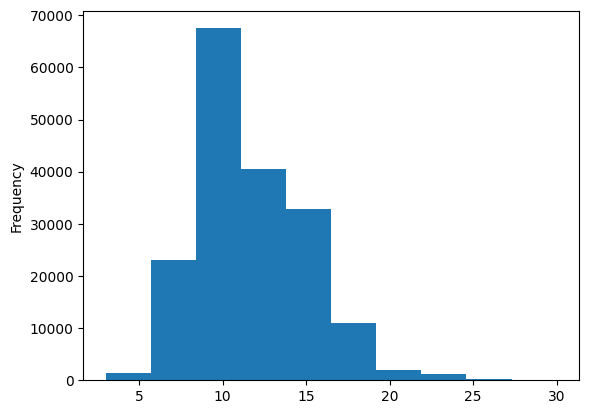

In [10]:
train_df.total_lines.plot.hist();

In [11]:
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()
len(train_sentences), len(val_sentences), len(test_sentences)

(180040, 30212, 30135)

In [12]:
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

In [13]:
# One hot encoding
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1, 1))

train_labels_one_hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 180040 stored elements and shape (180040, 5)>

In [14]:
# Label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_labels_encoded = label_encoder.transform(test_df["target"].to_numpy())

train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

In [15]:
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

## Preparing data for model

In [19]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

--2025-09-27 11:18:46--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-09-27 11:18:47 (102 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

In [17]:
sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_len = np.mean(sent_lens)
avg_sent_len

np.float64(26.338269273494777)

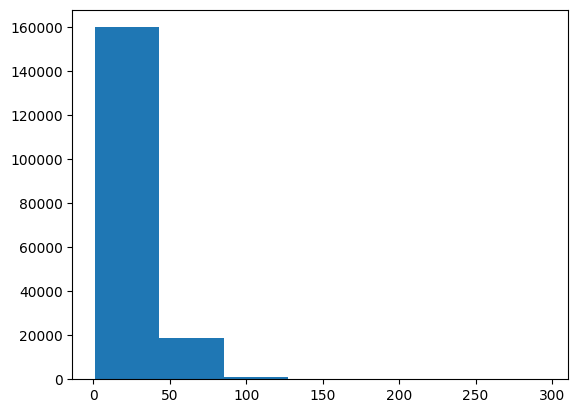

In [18]:
import matplotlib.pyplot as plt
plt.hist(sent_lens, bins=7);

In [19]:
output_seq_len = int(np.percentile(sent_lens, 95))
output_seq_len

55

Create text vectorizer

In [20]:
max_tokens = 68000  # number of words in vocabulary

In [21]:
from tensorflow.keras.layers import TextVectorization

In [22]:
text_vectorizer = TextVectorization(max_tokens=max_tokens,
                                    output_sequence_length=55)

In [23]:
# Adapt text vectorizer to training sentences
text_vectorizer.adapt(train_sentences)

In [24]:
# Test it
import random
target_sentence = random.choice(train_sentences)
print(f"Text:\n{target_sentence}")
print(f"\nLength of text: {len(target_sentence.split())}")
print(f"\nVectorized text:\n{text_vectorizer([target_sentence])}")

Text:
significant differences were found between men in the intervention and control arms ' reported ability to control their hostility and manage conflict ( arr @ , @ % ci @-@ @ ) , and participation in gendered household tasks ( arr @ , @ % ci @-@ @ ) .

Length of text: 50

Vectorized text:
[[   37   102     9   208    30   309     5     2    38     3    35   490
    205   805     6    35   120 17106     3  3620  4125  4917    50     3
   1064     5 38677  2995  1635  4917    50     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]]


In [25]:
# Number of words in our train vocabulary
rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f"Number of words in vocabulary: {len(rct_20k_text_vocab)}"),
print(f"Most common words in the vocabulary: {rct_20k_text_vocab[:5]}")
print(f"Least common words in the vocabulary: {rct_20k_text_vocab[-5:]}")

Number of words in vocabulary: 64841
Most common words in the vocabulary: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of')]
Least common words in the vocabulary: [np.str_('aainduced'), np.str_('aaigroup'), np.str_('aachener'), np.str_('aachen'), np.str_('aaacp')]


In [26]:
# Token embedding layer
token_embed = layers.Embedding(input_dim=len(rct_20k_text_vocab),
                               output_dim=128,
                               mask_zero=True,
                               name="token_embedding")

In [27]:
print(f"Sentence before vectorization:\n{target_sentence}\n")
vectorized_sentence = text_vectorizer([target_sentence])
print(f"Sentence after vectorization (before embedding):\n{vectorized_sentence}\n")
embedded_sentence = token_embed(vectorized_sentence)
print(f"Sentence after embedding:\n{embedded_sentence}\n")
print(f"Embedded sentence shape: {embedded_sentence.shape}")

Sentence before vectorization:
significant differences were found between men in the intervention and control arms ' reported ability to control their hostility and manage conflict ( arr @ , @ % ci @-@ @ ) , and participation in gendered household tasks ( arr @ , @ % ci @-@ @ ) .

Sentence after vectorization (before embedding):
[[   37   102     9   208    30   309     5     2    38     3    35   490
    205   805     6    35   120 17106     3  3620  4125  4917    50     3
   1064     5 38677  2995  1635  4917    50     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]]

Sentence after embedding:
[[[-0.02478     0.02775829  0.04418666 ... -0.03043559  0.02095023
    0.04379075]
  [ 0.03962976  0.02215148 -0.03130951 ...  0.01469848 -0.02613171
   -0.02337626]
  [ 0.0261228  -0.01490126 -0.03727863 ...  0.01862073 -0.0300875
    0.00464752]
  ...
  [ 0.04803276 -0.03596271 -0.0042031  ...  0.

In [28]:
# Turn our data into TensorFlow Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot.todense()))
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot.todense()))
test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot.todense()))

train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(5,), dtype=tf.float64, name=None))>

In [29]:
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

## Model 1 - Conv1D with token embeddings

In [35]:
inputs = layers.Input(shape=(1,), dtype=tf.string)
text_vectors = text_vectorizer(inputs)
token_embeddings = token_embed(text_vectors)
x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(token_embeddings)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_1 = tf.keras.Model(inputs, outputs)

# Compile
model_1.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [36]:
model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 55, 128)        │     8,299,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 55, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,340,997 (31.82 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Fit the model
model_1_history = model_1.fit(train_dataset,
                              steps_per_epoch=int(0.2 * len(train_dataset)),  # 20% of total dataset
                              epochs=10,
                              validation_data=valid_dataset,
                              validation_steps=int(0.2 * len(valid_dataset)))

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5942 - loss: 1.0001 - val_accuracy: 0.7702 - val_loss: 0.6296
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7743 - loss: 0.6165 - val_accuracy: 0.7951 - val_loss: 0.5717
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.7910 - loss: 0.5888 - val_accuracy: 0.8090 - val_loss: 0.5446
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8031 - loss: 0.5531 - val_accuracy: 0.8110 - val_loss: 0.5262
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8085 - loss: 0.5490 - val_accuracy: 0.8146 - val_loss: 0.5295
Epoch 6/10
   2/1125 ━━━━━━━━━━━━━━━━━━━━ 1:20 71ms/step - accuracy: 0.6938 - loss: 0.6475

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - accuracy: 0.7000 - loss: 0.6497 - val_accuracy: 0.8128 - val_loss: 0.5321
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8196 - loss: 0.5124 - val_accuracy: 0.8128 - val_loss: 0.5174
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8438 - loss: 0.4451 - val_accuracy: 0.8108 - val_loss: 0.5200
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8454 - loss: 0.4502 - val_accuracy: 0.8145 - val_loss: 0.5185
Epoch 10/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8481 - loss: 0.4310 - val_accuracy: 0.8161 - val_loss: 0.5146


In [38]:
model_1.evaluate(valid_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8129 - loss: 0.5224


[0.5274346470832825, 0.8116642236709595]

In [39]:
model_1.evaluate(test_dataset)

942/942 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8057 - loss: 0.5456


[0.5439156889915466, 0.8065704107284546]

In [40]:
model_1_pred_probs = model_1.predict(valid_dataset)
model_1_pred_probs

 82/945 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[7.71803737e-01, 4.90194671e-02, 4.22860123e-02, 1.22395247e-01,
        1.44954780e-02],
       [5.40956855e-01, 1.85799167e-01, 3.37006897e-03, 2.62628645e-01,
        7.24527379e-03],
       [1.13260686e-01, 3.46822757e-03, 1.72884858e-04, 8.83095503e-01,
        2.72717216e-06],
       ...,
       [4.03963850e-06, 7.20806202e-05, 7.92252738e-03, 4.77502499e-06,
        9.91996586e-01],
       [8.99958014e-02, 6.33316457e-01, 1.29129365e-01, 4.03658189e-02,
        1.07192494e-01],
       [1.33943632e-02, 9.72810686e-01, 1.22017739e-02, 2.14942978e-04,
        1.37833436e-03]], dtype=float32)

In [41]:
model_1_preds = tf.argmax(model_1_pred_probs, axis=1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 1, 1])>

In [43]:
from helper_functions import calculate_results

In [44]:
model_1_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_1_preds)
model_1_results

{'accuracy': 81.16642393750827,
 'precision': 0.8103060429910339,
 'recall': 0.8116642393750827,
 'f1': 0.8104702259998725}

# Model 2 - USE (Universal Sentence Encoder)

In [34]:
# Download USE
import tensorflow_hub as hub
tf_hub_embedding_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                        trainable=False,
                                        name="universal_sentence_encoder")

In [35]:
# Test it
random_training_sentence = random.choice(train_sentences)
print(f"Random training sentence:\n{random_training_sentence}\n")
use_embedded_sentence = tf_hub_embedding_layer([random_training_sentence])
print(f"Sentence after embedding:\n{use_embedded_sentence[0][:30]} (truncated output)...\n")
print(f"Length of sentence embedding:\n{len(use_embedded_sentence[0])}")

Random training sentence:
this study is a randomized , open and prospective trial .

Sentence after embedding:
[ 0.02137415  0.03488607 -0.06561502 -0.00274208 -0.06310462  0.01913563
  0.04717672  0.02028625  0.05272048 -0.04423615  0.04413778  0.01532724
  0.0831456   0.04289797 -0.01403488 -0.04262792 -0.04933142  0.06270255
  0.06884079 -0.06251196  0.03877116  0.05519051 -0.05558324 -0.03065742
 -0.0410105   0.01512098  0.0418425  -0.0242238   0.01591164 -0.04484897] (truncated output)...

Length of sentence embedding:
512


In [68]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers

# Wrap the KerasLayer in a Keras-compatible Layer
class USEEmbeddingLayer(layers.Layer):
    def __init__(self):
        super(USEEmbeddingLayer, self).__init__()
        self.use = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

    def call(self, inputs):
        return self.use(inputs)

# Build model
inputs = layers.Input(shape=(), dtype=tf.string)
x = USEEmbeddingLayer()(inputs)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(5, activation="softmax")(x)
model_2 = keras.Model(inputs=inputs, outputs=outputs)

# Compile
model_2.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [69]:
model_2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ use_embedding_layer_1           │ (None, 512)            │             0 │
│ (USEEmbeddingLayer)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,309 (259.02 KB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_2.fit(train_dataset,
            steps_per_epoch=int(0.2 * len(train_dataset)),
            epochs=10,
            validation_data=valid_dataset,
            validation_steps=int(0.2 * len(valid_dataset)))

In [ ]:
model_2.evaluate(valid_dataset)

In [ ]:
model_2_pred_probs = model_2.predict(valid_dataset)
model_2_pred_probs

In [ ]:
model_2_preds = tf.argmax(model_2_pred_probs, axis=1)
model_2_preds

In [ ]:
model_2_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_2_preds)
model_2_results

## Model 3 - With Character embeddings

In [36]:
def split_chars(text):
  return " ".join(list(text))

In [37]:
split_chars(random_training_sentence)

't h i s   s t u d y   i s   a   r a n d o m i z e d   ,   o p e n   a n d   p r o s p e c t i v e   t r i a l   .'

In [38]:
train_chars = [split_chars(sentence) for sentence in train_sentences]
val_chars = [split_chars(sentence) for sentence in val_sentences]
test_chars = [split_chars(sentence) for sentence in test_sentences]
print(train_chars[0])

t o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .


In [39]:
# What's the average character length?
char_lens = [len(sentence) for sentence in train_sentences]
mean_char_len = np.mean(char_lens)
mean_char_len

np.float64(149.3662574983337)

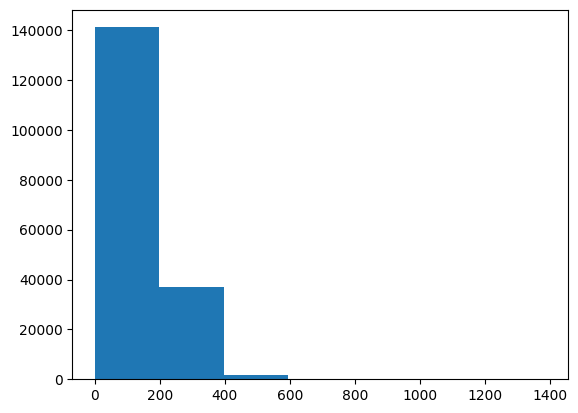

In [40]:
import matplotlib.pyplot as plt
plt.hist(char_lens, bins=7);

In [41]:
output_seq_char_len = int(np.percentile(char_lens, 95))
output_seq_char_len

290

In [42]:
import string
alphabet = string.ascii_lowercase + string.digits + string.punctuation
alphabet

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [43]:
NUM_CHAR_TOKENS = len(alphabet) + 2
char_vectorizer = TextVectorization(max_tokens=NUM_CHAR_TOKENS,
                                    output_sequence_length=output_seq_char_len,
                                    standardize="lower_and_strip_punctuation",
                                    name="char_vectorizer")

char_vectorizer.adapt(train_chars)

In [44]:
# Check character vocabulary characteristics
char_vocab = char_vectorizer.get_vocabulary()
print(f"Number of different characters in character vocab: {len(char_vocab)}")
print(f"5 most common characters: {char_vocab[:5]}")
print(f"5 least common characters: {char_vocab[-5:]}")

Number of different characters in character vocab: 28
5 most common characters: ['', '[UNK]', np.str_('e'), np.str_('t'), np.str_('i')]
5 least common characters: [np.str_('k'), np.str_('x'), np.str_('z'), np.str_('q'), np.str_('j')]


In [45]:
# Test it
random_train_chars = random.choice(train_chars)
print(f"Charified text:\n{random_train_chars}")
print(f"\nLength of chars: {len(random_train_chars.split())}")
vectorized_chars = char_vectorizer([random_train_chars])
print(f"\nVectorized chars:\n{vectorized_chars}")
print(f"\nLength of vectorized chars: {len(vectorized_chars[0])}")

Charified text:
w e   c o n d u c t e d   a   p r a g m a t i c   ,   r a n d o m i z e d   ,   u n b l i n d e d   ,   m u l t i c e n t e r   ,   p a r a l l e l - g r o u p   c l i n i c a l   t r i a l   (   t h e   s t a n d a r d   a n d   n e w   a n t i e p i l e p t i c   d r u g s   - l s b -   s a n a d   - r s b -   t r i a l   )   c o m p a r i n g   c l i n i c a l   a n d   c o s t   e f f e c t i v e n e s s   o f   i n i t i a t i n g   t r e a t m e n t   w i t h   c a r b a m a z e p i n e   v e r s u s   l a m o t r i g i n e   ,   g a b a p e n t i n   ,   o x c a r b a z e p i n e   a n d   t o p i r a m a t e   ,   a n d   v a l p r o a t e   v e r s u s   l a m o t r i g i n e   a n d   t o p i r a m a t e   .

Length of chars: 313

Vectorized chars:
[[20  2 11  7  6 10 16 11  3  2 10  5 14  8  5 18 15  5  3  4 11  8  5  6
  10  7 15  4 25  2 10 16  6 22 12  4  6 10  2 10 15 16 12  3  4 11  2  6
   3  2  8 14  5  8  5 12 12  2 12 18  8  7 16 14 11 12  4  6  4 11

In [46]:
# Create char embedding layer
char_embed = layers.Embedding(input_dim=NUM_CHAR_TOKENS,
                              output_dim=25,
                              mask_zero=False,
                              name="char_embed")

In [47]:
print(f"Charified text (before vectorization and embedding):\n{random_train_chars}\n")
char_embed_example = char_embed(char_vectorizer([random_train_chars]))
print(f"Embedded chars (after vectorization and embedding):\n{char_embed_example}\n")
print(f"Character embedding shape: {char_embed_example.shape}")

Charified text (before vectorization and embedding):
w e   c o n d u c t e d   a   p r a g m a t i c   ,   r a n d o m i z e d   ,   u n b l i n d e d   ,   m u l t i c e n t e r   ,   p a r a l l e l - g r o u p   c l i n i c a l   t r i a l   (   t h e   s t a n d a r d   a n d   n e w   a n t i e p i l e p t i c   d r u g s   - l s b -   s a n a d   - r s b -   t r i a l   )   c o m p a r i n g   c l i n i c a l   a n d   c o s t   e f f e c t i v e n e s s   o f   i n i t i a t i n g   t r e a t m e n t   w i t h   c a r b a m a z e p i n e   v e r s u s   l a m o t r i g i n e   ,   g a b a p e n t i n   ,   o x c a r b a z e p i n e   a n d   t o p i r a m a t e   ,   a n d   v a l p r o a t e   v e r s u s   l a m o t r i g i n e   a n d   t o p i r a m a t e   .

Embedded chars (after vectorization and embedding):
[[[ 0.02210528 -0.01772671  0.02288348 ... -0.03007195  0.00420465
    0.03017691]
  [ 0.00963297  0.02322036  0.03144621 ... -0.0379991   0.03782703
    0.01205397]


In [85]:
# Conv1D model
inputs = layers.Input(shape=(1,), dtype="string")
char_vectors = char_vectorizer(inputs)
char_embeddings = char_embed(char_vectors)
x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(char_embeddings)
x = layers.GlobalMaxPool1D()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_3 = tf.keras.Model(inputs=inputs,
                         outputs=outputs,
                         name="model_3_conv1D_char_embedding")

model_3.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [86]:
model_3.summary()

Model: "model_3_conv1D_char_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_vectorizer                 │ (None, 290)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ char_embed (Embedding)          │ (None, 290, 25)        │         1,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 290, 64)        │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,139 (39.61 KB)

 Trainable params: 10,139 (39.61 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
train_char_dataset = tf.data.Dataset.from_tensor_slices((train_chars, train_labels_one_hot.todense())).batch(32).prefetch(tf.data.AUTOTUNE)
val_char_dataset = tf.data.Dataset.from_tensor_slices((val_chars, val_labels_one_hot.todense())).batch(32).prefetch(tf.data.AUTOTUNE)

train_char_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

In [89]:
model_3_history = model_3.fit(train_char_dataset,
                              steps_per_epoch=int(0.2 * len(train_char_dataset)),
                              epochs=10,
                              validation_data=val_char_dataset,
                              validation_steps=int(0.2 * len(val_char_dataset)))

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4796 - loss: 1.2782 - val_accuracy: 0.6453 - val_loss: 0.9174
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6461 - loss: 0.9033 - val_accuracy: 0.6837 - val_loss: 0.8216
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6731 - loss: 0.8397 - val_accuracy: 0.6963 - val_loss: 0.7859
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6860 - loss: 0.8101 - val_accuracy: 0.7067 - val_loss: 0.7646
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7017 - loss: 0.7857 - val_accuracy: 0.7044 - val_loss: 0.7627
Epoch 6/10
   2/1125 ━━━━━━━━━━━━━━━━━━━━ 58s 52ms/step - accuracy: 0.6281 - loss: 0.8863

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step - accuracy: 0.6001 - loss: 0.9212 - val_accuracy: 0.7052 - val_loss: 0.7650
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7074 - loss: 0.7746 - val_accuracy: 0.7158 - val_loss: 0.7433
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7142 - loss: 0.7475 - val_accuracy: 0.7174 - val_loss: 0.7286
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7192 - loss: 0.7452 - val_accuracy: 0.7244 - val_loss: 0.7167
Epoch 10/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7187 - loss: 0.7406 - val_accuracy: 0.7232 - val_loss: 0.7156


In [90]:
model_3.evaluate(val_char_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7218 - loss: 0.7241


[0.7261399626731873, 0.7235866785049438]

In [91]:
model_3_pred_probs = model_3.predict(val_char_dataset)
model_3_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


array([[1.65837049e-01, 2.89748251e-01, 3.30322795e-03, 5.32806516e-01,
        8.30494426e-03],
       [9.53070745e-02, 8.48420978e-01, 4.15523304e-04, 5.18128537e-02,
        4.04358702e-03],
       [4.16283645e-02, 3.70495282e-02, 8.28531978e-04, 9.19233143e-01,
        1.26043602e-03],
       ...,
       [2.71752756e-02, 1.54038491e-02, 6.72924817e-02, 7.17339143e-02,
        8.18394482e-01],
       [3.75711247e-02, 2.55430013e-01, 2.32951492e-01, 9.04611573e-02,
        3.83586198e-01],
       [1.14578485e-01, 8.30845892e-01, 2.58151833e-02, 2.23139171e-02,
        6.44653803e-03]], dtype=float32)

In [92]:
model_3_preds = tf.argmax(model_3_pred_probs, axis=1)
model_3_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([3, 1, 3, ..., 4, 4, 1])>

In [93]:
model_3_results = calculate_results(y_true=val_labels_encoded,
                                        y_pred=model_3_preds)
model_3_results

{'accuracy': 72.35866543095459,
 'precision': 0.7235027809847359,
 'recall': 0.7235866543095458,
 'f1': 0.7204462266160614}

## Model 4 - Hybrid (Token + character embeddings)

In [48]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

# Wrap the KerasLayer in a Keras-compatible Layer
class USEEmbeddingLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(USEEmbeddingLayer, self).__init__(**kwargs)
        # Load the Universal Sentence Encoder model
        self.use = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

    def call(self, inputs):
        # The loaded model is callable and accepts tensors
        return self.use(inputs)

# 1. Setup token inputs/model
token_inputs = layers.Input(shape=(), dtype=tf.string, name="token_input")
token_embeddings = USEEmbeddingLayer()(token_inputs)
token_output = layers.Dense(128, activation="relu")(token_embeddings)
token_model = tf.keras.Model(inputs=token_inputs,
                             outputs=token_output)

# 2. Setup char inputs/model
char_inputs = layers.Input(shape=(1,), dtype=tf.string, name="char_input")
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)
char_bi_lstm = layers.Bidirectional(layers.LSTM(25))(char_embeddings)
char_model = tf.keras.Model(inputs=char_inputs,
                            outputs=char_bi_lstm)

# 3. Concatenate token and char inputs (create hybrid token embedding)
token_char_concat = layers.Concatenate(name="token_char_hybrid")([token_model.output,
                                                                  char_model.output])

# 4. Create output layers
combined_dropout = layers.Dropout(0.5)(token_char_concat)
combined_dense = layers.Dense(200, activation="relu")(combined_dropout)
final_dropout = layers.Dropout(0.5)(combined_dense)
output_layer = layers.Dense(num_classes, activation="softmax")(final_dropout)

# 5. Construct model with char and token inputs
model_4 = tf.keras.Model(inputs=[token_model.input, char_model.input],
                         outputs=output_layer,
                         name="model_4_token_and_char_embeddings")

In [49]:
model_4.summary()

Model: "model_4_token_and_char_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_input         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_embedding_laye… │ (None, 512)       │          0 │ token_input[0][0] │
│ (USEEmbeddingLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │      1,750 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ use_embedding_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50)        │     10,200 │ char_embed[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid   │ (None, 178)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 178)       │          0 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 200)       │     35,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 200)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │      1,005 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,419 (446.95 KB)

 Trainable params: 114,419 (446.95 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
!apt-get install graphviz
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


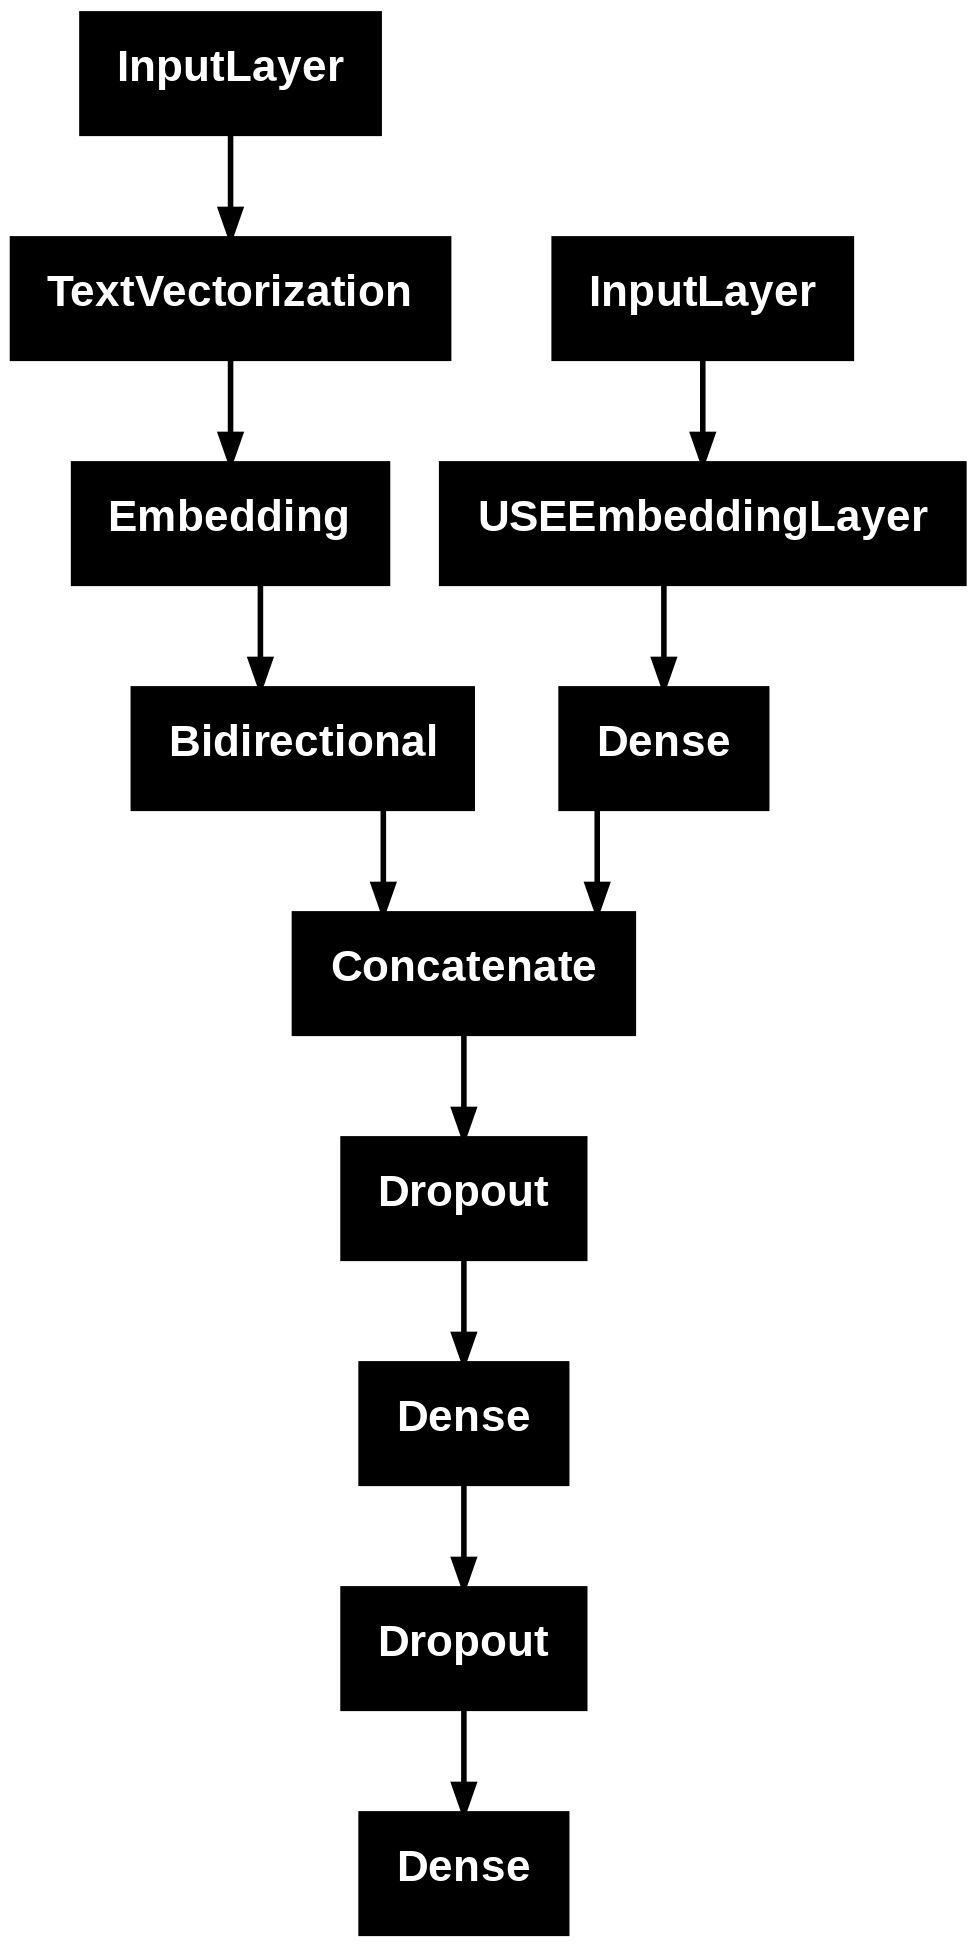

In [50]:
from tensorflow.keras.utils import plot_model
plot_model(model_4)

In [51]:
model_4.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [53]:
# Combine chars and tokens into a dataset
train_char_token_data = tf.data.Dataset.from_tensor_slices((train_sentences, train_chars)) # make data
train_char_token_labels = tf.data.Dataset.from_tensor_slices(train_labels_one_hot.todense()) # make labels, convert to dense
train_char_token_dataset = tf.data.Dataset.zip((train_char_token_data, train_char_token_labels)) # combine data and labels

# Prefetch and batch train data
train_char_token_dataset = train_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Repeat same steps validation data
val_char_token_data = tf.data.Dataset.from_tensor_slices((val_sentences, val_chars))
val_char_token_labels = tf.data.Dataset.from_tensor_slices(val_labels_one_hot.todense()) # convert to dense
val_char_token_dataset = tf.data.Dataset.zip((val_char_token_data, val_char_token_labels))
val_char_token_dataset = val_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [54]:
model_4_history = model_4.fit(train_char_token_dataset,
                              steps_per_epoch=int(0.2 * len(train_char_token_dataset)),
                              epochs=10,
                              validation_data=val_char_token_dataset,
                              validation_steps=int(0.2 * len(val_char_token_dataset)))

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - accuracy: 0.6517 - loss: 0.8815 - val_accuracy: 0.7305 - val_loss: 0.7156
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.7133 - loss: 0.7511 - val_accuracy: 0.7444 - val_loss: 0.6735
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.7168 - loss: 0.7446 - val_accuracy: 0.7560 - val_loss: 0.6505
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.7286 - loss: 0.7105 - val_accuracy: 0.7621 - val_loss: 0.6378
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.7338 - loss: 0.7006 - val_accuracy: 0.7636 - val_loss: 0.6277
Epoch 6/10
   1/1125 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.6875 - loss: 0.7940

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6750 - loss: 0.8741 - val_accuracy: 0.7639 - val_loss: 0.6273
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.7372 - loss: 0.6866 - val_accuracy: 0.7698 - val_loss: 0.6154
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.7464 - loss: 0.6780 - val_accuracy: 0.7641 - val_loss: 0.6210
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.7381 - loss: 0.6913 - val_accuracy: 0.7708 - val_loss: 0.6057
Epoch 10/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.7497 - loss: 0.6644 - val_accuracy: 0.7750 - val_loss: 0.5992


In [55]:
model_4.evaluate(val_char_token_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7714 - loss: 0.6014


[0.601431131362915, 0.7714484333992004]

In [56]:
model_4_pred_probs = model_4.predict(val_char_token_dataset)
model_4_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step


array([[5.0852782e-01, 2.8993329e-01, 2.2590824e-03, 1.9292997e-01,
        6.3498360e-03],
       [3.6468133e-01, 5.3731757e-01, 5.4359678e-03, 9.0373911e-02,
        2.1912206e-03],
       [4.9053681e-01, 1.0174215e-02, 1.1341074e-02, 4.8558342e-01,
        2.3644660e-03],
       ...,
       [7.7146025e-05, 5.6488352e-04, 2.1802800e-02, 2.2225577e-05,
        9.7753292e-01],
       [1.9337893e-02, 1.3506751e-01, 1.8333258e-01, 6.6442289e-03,
        6.5561771e-01],
       [8.3460093e-02, 8.9095956e-01, 2.1451540e-02, 1.1000858e-03,
        3.0287264e-03]], dtype=float32)

In [57]:
model_4_preds = tf.argmax(model_4_pred_probs, axis=1)
model_4_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 0, ..., 4, 4, 1])>

In [60]:
model_4_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_4_preds)
model_4_results

{'accuracy': 77.14484310869854,
 'precision': 0.7695089365102962,
 'recall': 0.7714484310869854,
 'f1': 0.7679397965356445}

## Model 5 - TL with pretrained token embeddings + char embeddings + positional embeddings

In [61]:
train_df.head()

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


<Axes: ylabel='Frequency'>

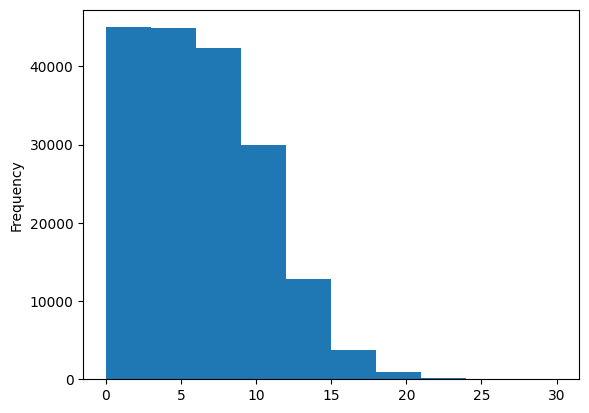

In [62]:
train_df.line_number.plot.hist()

In [63]:
train_line_numbers_one_hot = tf.one_hot(train_df["line_number"].to_numpy(), depth=15)
val_line_numbers_one_hot = tf.one_hot(val_df["line_number"].to_numpy(), depth=15)
test_line_numbers_one_hot = tf.one_hot(test_df["line_number"].to_numpy(), depth=15)

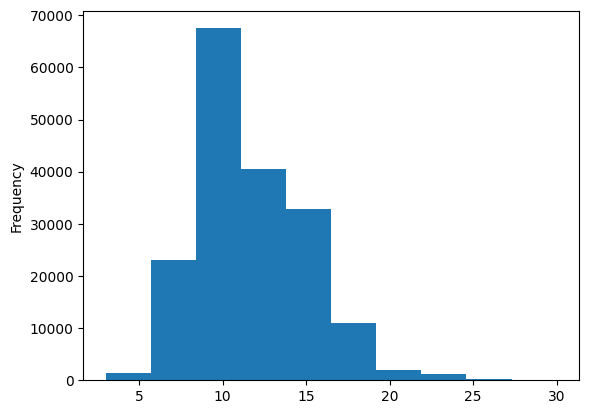

In [64]:
train_df.total_lines.plot.hist();

In [65]:
np.percentile(train_df.total_lines, 98)

np.float64(20.0)

In [66]:
train_total_lines_one_hot = tf.one_hot(train_df["total_lines"].to_numpy(), depth=20)
val_total_lines_one_hot = tf.one_hot(val_df["total_lines"].to_numpy(), depth=20)
test_total_lines_one_hot = tf.one_hot(test_df["total_lines"].to_numpy(), depth=20)

In [71]:
# 1. Token inputs
class USEEmbeddingLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(USEEmbeddingLayer, self).__init__(**kwargs)
        # Load the Universal Sentence Encoder model
        self.use = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

    def call(self, inputs):
        # The loaded model is callable and accepts tensors
        return self.use(inputs)

token_inputs = layers.Input(shape=(), dtype=tf.string, name="token_input")
token_embeddings = USEEmbeddingLayer()(token_inputs)
token_output = layers.Dense(128, activation="relu")(token_embeddings)
token_model = tf.keras.Model(inputs=token_inputs,
                             outputs=token_output)

# 2. Char inputs
char_inputs = layers.Input(shape=(1,), dtype="string", name="char_inputs")
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)
char_bi_lstm = layers.Bidirectional(layers.LSTM(32))(char_embeddings)
char_model = tf.keras.Model(inputs=char_inputs,
                            outputs=char_bi_lstm)

# 3. Line numbers inputs
line_number_inputs = layers.Input(shape=(15,), dtype=tf.int32, name="line_number_input")
x = layers.Dense(32, activation="relu")(line_number_inputs)
line_number_model = tf.keras.Model(inputs=line_number_inputs,
                                   outputs=x)

# 4. Total lines inputs
total_lines_inputs = layers.Input(shape=(20,), dtype=tf.int32, name="total_lines_input")
y = layers.Dense(32, activation="relu")(total_lines_inputs)
total_line_model = tf.keras.Model(inputs=total_lines_inputs,
                                  outputs=y)

# 5. Combine token and char embeddings into a hybrid embedding
combined_embeddings = layers.Concatenate(name="token_char_hybrid_embedding")([token_model.output,
                                                                              char_model.output])
z = layers.Dense(256, activation="relu")(combined_embeddings)
z = layers.Dropout(0.5)(z)

# 6. Combine positional embeddings with combined token and char embeddings into a tribrid embedding
z = layers.Concatenate(name="token_char_positional_embedding")([line_number_model.output,
                                                                total_line_model.output,
                                                                z])

# 7. Create output layer
output_layer = layers.Dense(5, activation="softmax", name="output_layer")(z)

# 8. Put together model
model_5 = tf.keras.Model(inputs=[line_number_model.input,
                                 total_line_model.input,
                                 token_model.input,
                                 char_model.input],
                         outputs=output_layer)

In [72]:
model_5.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_inputs         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_input         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_inputs[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_embedding_laye… │ (None, 512)       │          0 │ token_input[0][0] │
│ (USEEmbeddingLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │      1,750 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     65,664 │ use_embedding_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     14,848 │ char_embed[1][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid_… │ (None, 192)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ line_number_input   │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ total_lines_input   │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     49,408 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        512 │ line_number_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │        672 │ total_lines_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_positio… │ (None, 320)       │          0 │ dense_5[0][0],    │
│ (Concatenate)       │                   │            │ dense_6[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 5)         │      1,605 │ token_char_posit… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 134,459 (525.23 KB)

 Trainable params: 134,459 (525.23 KB)

 Non-trainable params: 0 (0.00 B)

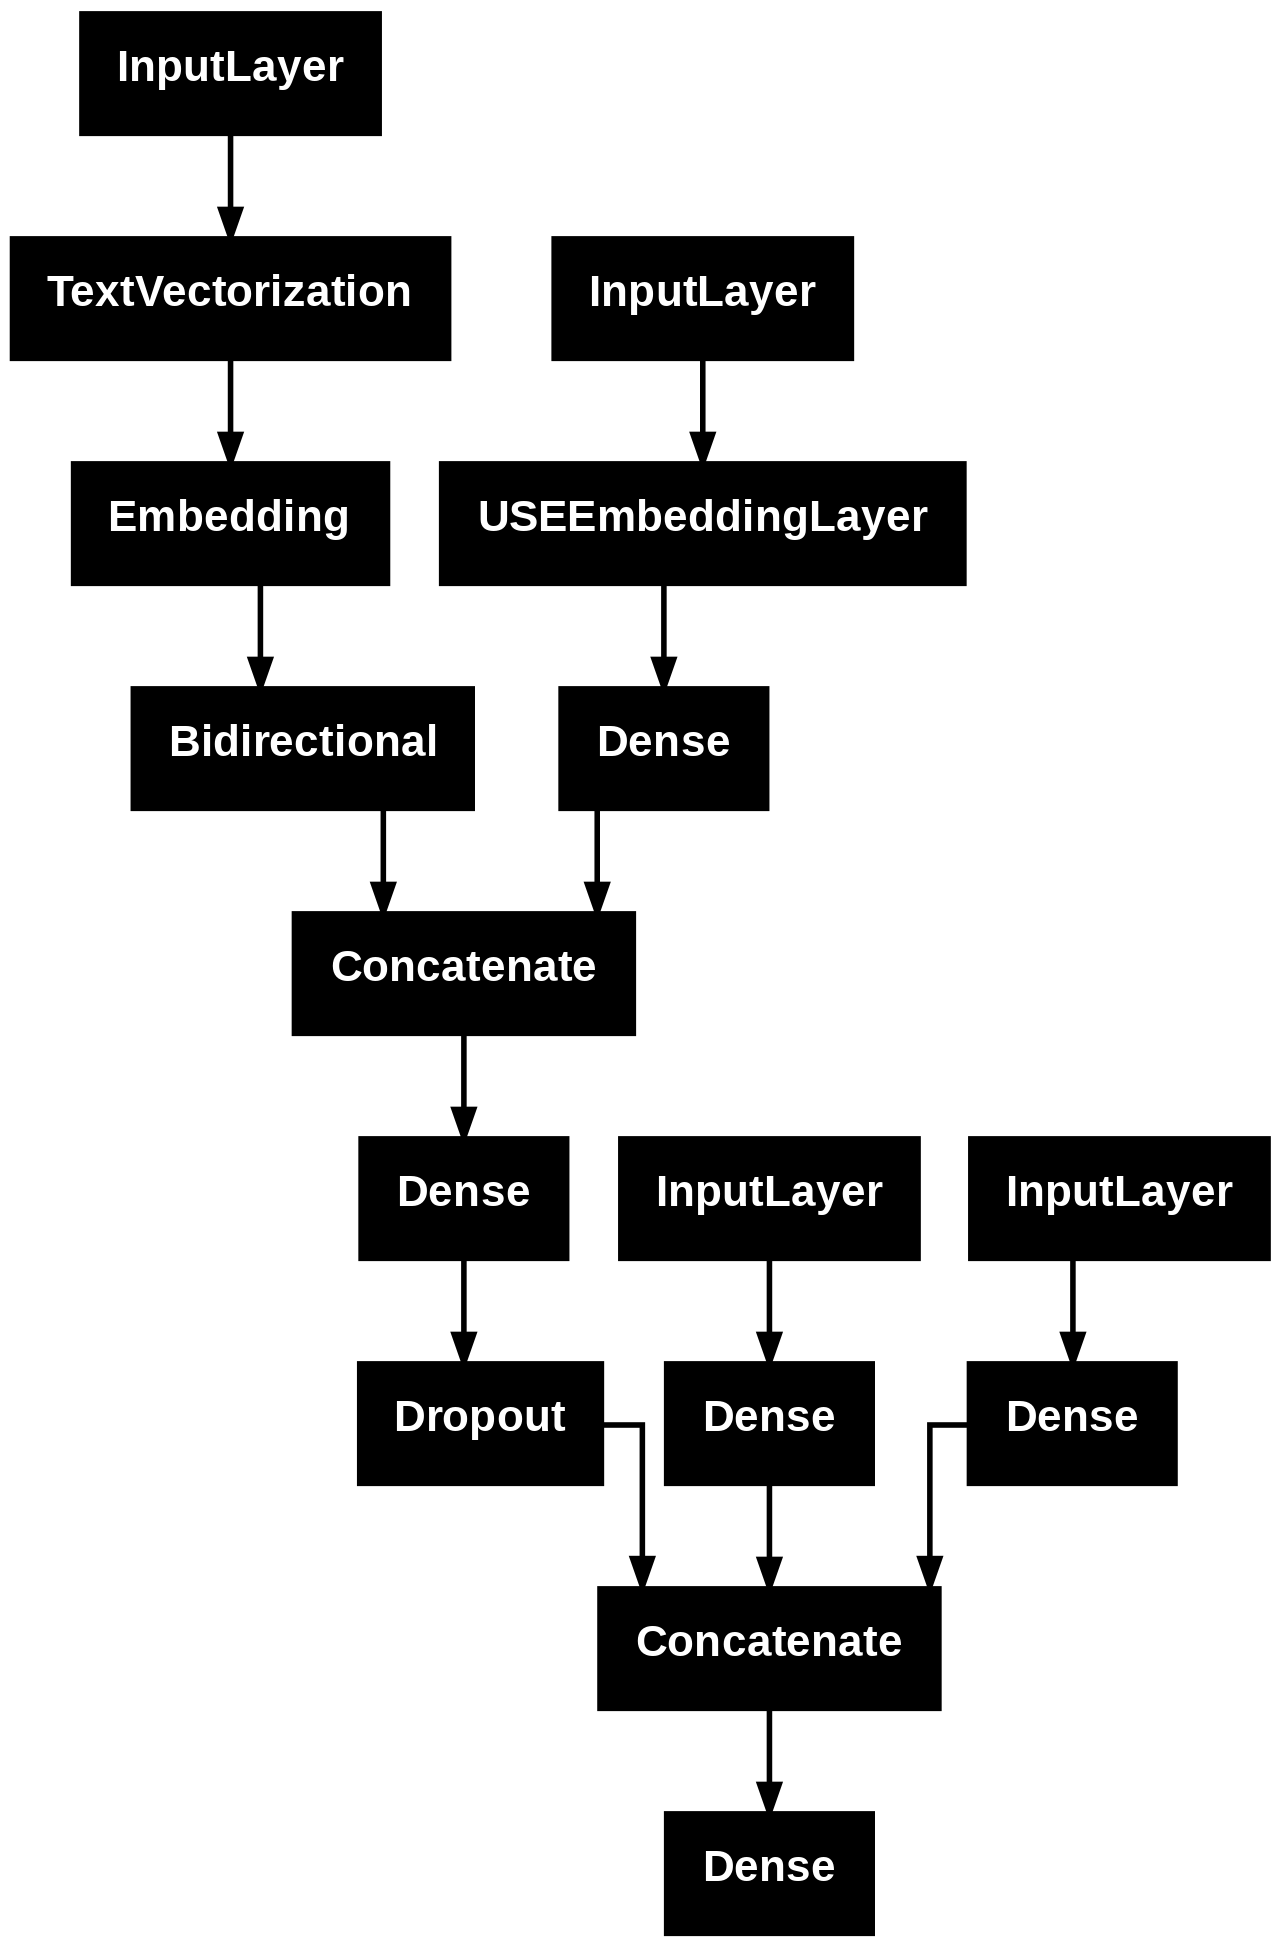

In [73]:
from tensorflow.keras.utils import plot_model
plot_model(model_5)

In [74]:
model_5.compile(loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [76]:
train_pos_char_token_data = tf.data.Dataset.from_tensor_slices((train_line_numbers_one_hot,
                                                                train_total_lines_one_hot,
                                                                train_sentences,
                                                                train_chars))
train_pos_char_token_labels = tf.data.Dataset.from_tensor_slices(train_labels_one_hot.todense())
train_pos_char_token_dataset = tf.data.Dataset.zip((train_pos_char_token_data, train_pos_char_token_labels))
train_pos_char_token_dataset = train_pos_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Validation dataset
val_pos_char_token_data = tf.data.Dataset.from_tensor_slices((val_line_numbers_one_hot,
                                                              val_total_lines_one_hot,
                                                              val_sentences,
                                                              val_chars))
val_pos_char_token_labels = tf.data.Dataset.from_tensor_slices(val_labels_one_hot.todense())
val_pos_char_token_dataset = tf.data.Dataset.zip((val_pos_char_token_data, val_pos_char_token_labels))
val_pos_char_token_dataset = val_pos_char_token_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


In [77]:
history_model_5 = model_5.fit(train_pos_char_token_dataset,
                              steps_per_epoch=int(0.4 * len(train_pos_char_token_dataset)),
                              epochs=12,
                              validation_data=val_pos_char_token_dataset,
                              validation_steps=int(0.4 * len(val_pos_char_token_dataset)))

Epoch 1/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.7970 - loss: 0.9906 - val_accuracy: 0.8333 - val_loss: 0.9296
Epoch 2/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.8367 - loss: 0.9329 - val_accuracy: 0.8500 - val_loss: 0.9107
Epoch 3/12
1127/2250 ━━━━━━━━━━━━━━━━━━━━ 33s 30ms/step - accuracy: 0.8391 - loss: 0.9281

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2250/2250 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.8434 - loss: 0.9242 - val_accuracy: 0.8445 - val_loss: 0.9113
Epoch 4/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.8509 - loss: 0.9125 - val_accuracy: 0.8479 - val_loss: 0.9067
Epoch 5/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 76s 34ms/step - accuracy: 0.8540 - loss: 0.9094 - val_accuracy: 0.8578 - val_loss: 0.8998
Epoch 6/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.8580 - loss: 0.9052 - val_accuracy: 0.8492 - val_loss: 0.9010
Epoch 7/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 74s 33ms/step - accuracy: 0.8619 - loss: 0.8982 - val_accuracy: 0.8502 - val_loss: 0.9007
Epoch 8/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 74s 33ms/step - accuracy: 0.8631 - loss: 0.8969 - val_accuracy: 0.8578 - val_loss: 0.8952
Epoch 9/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.8656 - loss: 0.8947 - val_accuracy: 0.8481 - val_loss: 0.9010
Epoch 10/12
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.8696 - loss: 0.8

In [78]:
model_5_pred_probs = model_5.predict(val_pos_char_token_dataset, verbose=1)
model_5_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step


array([[0.57719946, 0.08927356, 0.02511673, 0.2806317 , 0.02777849],
       [0.5908618 , 0.11164881, 0.04270733, 0.23346272, 0.02131932],
       [0.39891276, 0.07818376, 0.05049812, 0.43276232, 0.03964305],
       ...,
       [0.02667805, 0.08841576, 0.01700681, 0.0338162 , 0.8340832 ],
       [0.01967237, 0.29805684, 0.0555599 , 0.02487522, 0.60183567],
       [0.04126607, 0.8709706 , 0.04390376, 0.02956736, 0.0142922 ]],
      dtype=float32)

In [79]:
model_5_preds = tf.argmax(model_5_pred_probs, axis=1)
model_5_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>

In [80]:
model_5_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_5_preds)
model_5_results

{'accuracy': 85.23765391235271,
 'precision': 0.8548996041250949,
 'recall': 0.8523765391235271,
 'f1': 0.8492890226757066}

## Compare model results

In [ ]:
# Combine model results into a DataFrame
all_model_results = pd.DataFrame({"baseline": baseline_results,
                                  "custom_token_embed_conv1d": model_1_results,
                                  "pretrained_token_embed": model_2_results,
                                  "custom_char_embed_conv1d": model_3_results,
                                  "hybrid_char_token_embed": model_4_results,
                                  "tribrid_pos_char_token_embed": model_5_results})
all_model_results = all_model_results.transpose()
all_model_results

In [ ]:
all_model_results["accuracy"] = all_model_results["accuracy"]/100
all_model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0));